# Gradient and Relaxation Analysis with Noise
## Using WC_loss with Poisson noise and timing jitter

In [3]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

import sys
sys.path.append('..')

from tools.geometry import generate_detector
from tools.utils import load_single_event, save_single_event, generate_random_params, print_particle_params
from tools.losses import WC_loss
from tools.simulation import setup_event_simulator

import jax
import jax.numpy as jnp
import time

from jax import jit
from pathlib import Path

from matplotlib import pyplot as plt
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10

import numpy as np
from functools import partial
import pickle
from tqdm import tqdm
from jax import grad, jit, vmap, value_and_grad

## Setup Detector and Event Simulators

In [4]:
default_json_filename = '../config/IWCD_geom_config.json'

detector = generate_detector(default_json_filename)
detector_points = jnp.array(detector.all_points)
detector_radius = detector.S_radius
NUM_DETECTORS = len(detector_points)
Nphot = 1_000_000

# Define temperatures for analysis
temperatures = [0.0, 0.2]

# Setup event simulators for each temperature
event_simulators = {temperature: setup_event_simulator(default_json_filename, Nphot, temperature) 
                    for temperature in temperatures}

# Setup true data simulator (no temperature relaxation)
simulate_true_data = setup_event_simulator(default_json_filename, Nphot, temperature=None, 
                                          is_data=False, is_calibration=False)

print(f"Number of detectors: {NUM_DETECTORS}")
print(f"Temperatures for analysis: {temperatures}")

Number of detectors: 9720
Temperatures for analysis: [0.0, 0.2]


## Noise Functions

In [5]:
def add_poisson_noise(pe_values, key):
    """
    Add Poisson fluctuations to PE values
    
    Args:
        pe_values: array of expected PE counts
        key: JAX random key
    
    Returns:
        observed_pe: Poisson-sampled PE counts
    """
    return jax.random.poisson(key, pe_values)

def add_timing_noise(pe_values, times, key, tts=0.2):
    """
    Add transit time spread (TTS) noise to timing measurements.
    Noise is scaled by 1/sqrt(PE) for multi-PE hits.
    """
    noise = jax.random.normal(key, shape=times.shape) * tts
    
    # Scale noise by 1/sqrt(PE), cap at single PE
    scaling = jnp.where(
        pe_values >= 1.0,
        1.0 / jnp.sqrt(pe_values),
        1.0
    )
    
    # Only add noise where PE > 0
    noisy_times = jnp.where(
        pe_values > 0,
        times + noise * scaling,
        times
    )
    
    return noisy_times

def add_detector_noise(charge_time_tuple, key, tts=0.2):
    """
    Add noise to both charge (PE) and timing
    
    Args:
        charge_time_tuple: (charge_array, time_array)
        key: JAX random key
        tts: transit time spread in ns
    
    Returns:
        (noisy_charge, noisy_time): tuple of arrays with noise added
    """
    charges, times = charge_time_tuple
    
    # Split key for two operations
    key1, key2 = jax.random.split(key)
    
    # Add Poisson noise to charges
    noisy_charges = add_poisson_noise(charges, key1)
    
    # Add timing noise (using noisy charges for scaling)
    noisy_times = add_timing_noise(noisy_charges, times, key2, tts)
    
    return (noisy_charges, noisy_times)

## Generate Test Event

In [6]:
# Generate true parameters
key = jax.random.PRNGKey(719007)
true_params = generate_random_params(key)

# Detector parameters
detector_params = (
    jnp.array(4.),           # scatter_length
    jnp.array(0.2),          # reflection_rate
    jnp.array(6.),           # absorption_length
    jnp.array(0.001)         # gumbel_softmax_temp
)

# Generate true data (no temperature relaxation)
true_data = jax.lax.stop_gradient(simulate_true_data(true_params, detector_params, key))

# Add noise to the true data
noise_key = jax.random.PRNGKey(12345)
noised_true_data = add_detector_noise(true_data, noise_key, tts=0.2)

save_single_event(noised_true_data, true_params, detector_params, filename='../events/noised_event_data.h5', calibration_mode=False)

print("True parameters:")
print(f"  Energy: {true_params[0]:.2f} MeV")
print(f"  Position: [{true_params[1][0]:.2f}, {true_params[1][1]:.2f}, {true_params[1][2]:.2f}] m")
print(f"  Direction: theta={true_params[2][0]:.2f} rad, phi={true_params[2][1]:.2f} rad")

True parameters:
  Energy: 628.12 MeV
  Position: [-0.81, 0.05, 0.23] m
  Direction: theta=2.12 rad, phi=4.21 rad


Particle Parameters:
  Energy: 628.12 MeV
  Position: [-0.81, 0.05, 0.23] m
  Direction angles: theta=2.12 rad, phi=4.21 rad
  Direction vector: [-0.41, -0.75, -0.52]


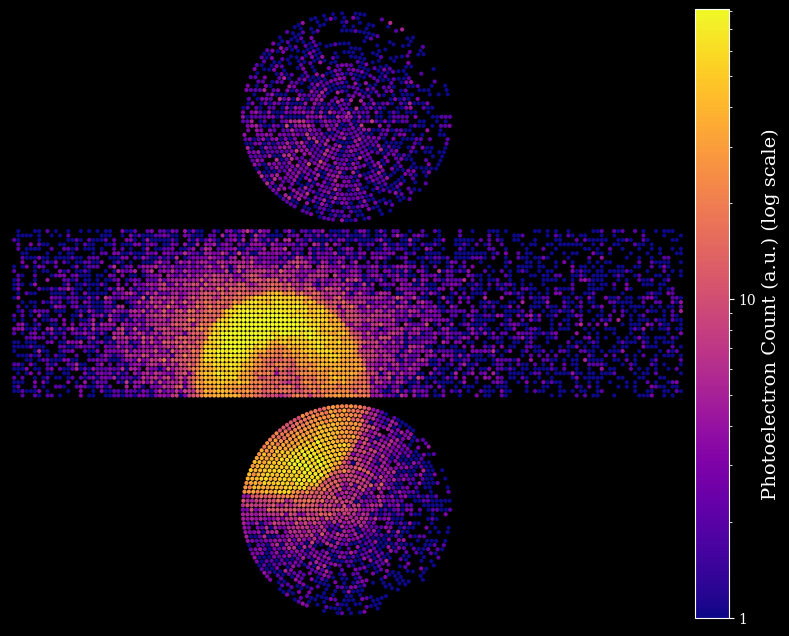

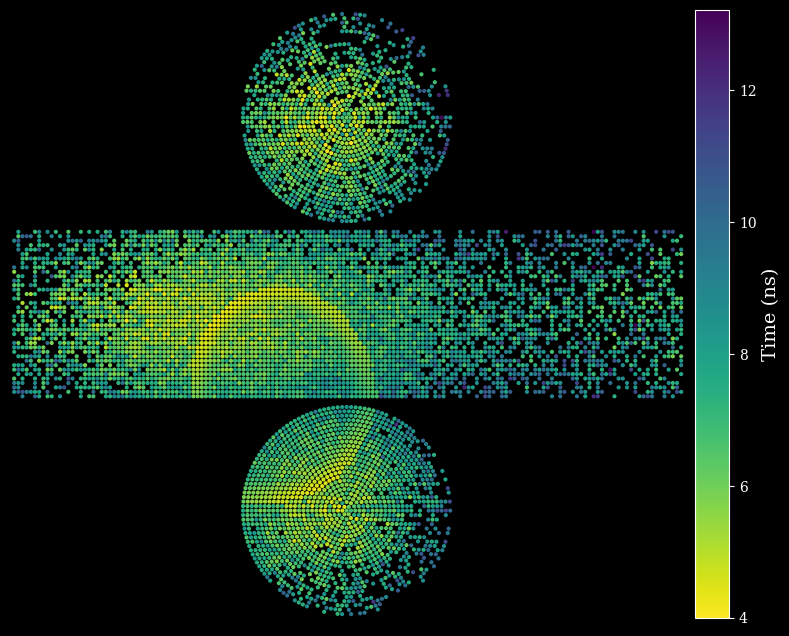

In [7]:
from tools.visualization import create_detector_display

event_location = '../events/noised_event_data.h5'

figures_dir = Path('figures')
figures_dir.mkdir(parents=True, exist_ok=True)

loaded_trk_params, loaded_detector_params, loaded_indices, loaded_charges, loaded_times= load_single_event(event_location, NUM_DETECTORS, calibration_mode=False)
print_particle_params(loaded_trk_params)#, print_detector_params(loaded_detector_params)

detector_display = create_detector_display(default_json_filename)
detector_display(loaded_indices, loaded_charges, loaded_times, file_name='figures/event_display_charge.png', plot_time=False, log_scale=True)
detector_display(loaded_indices, loaded_charges, loaded_times, file_name='figures/event_display_time.png', plot_time=True, log_scale=False, perc_min=0.0, perc_max=100.0)

## Hyperparameter Analysis Helper Functions

In [8]:
# Define parameter min/max ranges based on detector geometry
param_min_max = (
    (0.0001, 1000.0),                    # Energy in MeV (min, max)
    (-detector.r, detector.r),           # Position X in meters (min, max)
    (-detector.r, detector.r),           # Position Y in meters (min, max)
    (-detector.H/2, detector.H/2),       # Position Z in meters (min, max)
    (0, 3.14159),                         # Theta (polar angle) in radians: 0 to π
    (0, 6.28318)                          # Phi (azimuthal angle) in radians: 0 to 2π
)

# Calculate parameter ranges (max - min) for gradient scaling
param_range_scales = jnp.array([
    param_min_max[0][1] - param_min_max[0][0],  # Energy range
    param_min_max[1][1] - param_min_max[1][0],  # Position X range
    param_min_max[2][1] - param_min_max[2][0],  # Position Y range (not used in analysis)
    param_min_max[3][1] - param_min_max[3][0],  # Position Z range (not used in analysis)
    param_min_max[4][1] - param_min_max[4][0],  # Theta range
    param_min_max[5][1] - param_min_max[5][0]   # Phi range
])

# Define parameter changes for analysis
param_changes = (
    jnp.array(200.0),             # Energy in MeV
    jnp.array([1.5, 0.0, 0.0]),   # position
    jnp.array([1.0, 1.0])         # direction (theta, phi)
)

def generate_param_ranges(particle_params, param_changes, num_points=121):
    """Generate parameter ranges for analysis"""
    param_ranges = []
    
    # Energy
    start = max(particle_params[0] - param_changes[0], 0.0001)
    end = particle_params[0] + param_changes[0]
    param_ranges.append(jnp.linspace(start, end, num_points))
    
    # Position X
    start = particle_params[1][0] - param_changes[1][0]
    end = particle_params[1][0] + param_changes[1][0]
    param_ranges.append(jnp.linspace(start, end, num_points))
    
    # Theta
    start = particle_params[2][0] - param_changes[2][0]
    end = particle_params[2][0] + param_changes[2][0]
    param_ranges.append(jnp.linspace(start, end, num_points))
    
    # Phi
    start = particle_params[2][1] - param_changes[2][1]
    end = particle_params[2][1] + param_changes[2][1]
    param_ranges.append(jnp.linspace(start, end, num_points))
    
    return param_ranges

def generate_plot_data_wc(param_index, param_values, simulator, particle_params,
                         detector_params, key, true_data, detector_points,
                         lambda_poisson=1.0, lambda_time=1.0):
    """Generate loss and gradient data using WC_loss"""
    losses = []
    gradients = []
    
    @jit
    def loss_and_grad_fn(p_params, d_params):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return WC_loss(
                detector_points, *true_data, *simulated_data,
                lambda_poisson=lambda_poisson,
                lambda_time=lambda_time
            )
        return value_and_grad(loss_fn)(p_params)
    
    # Get the appropriate parameter range scale
    param_scale_indices = [0, 1, 4, 5]  # Energy, X, Theta, Phi
    param_scale = param_range_scales[param_scale_indices[param_index]]
    
    for new_value in param_values:
        # Modify particle parameter
        new_p_params = list(particle_params)
        
        if param_index == 0:  # Energy
            new_p_params[0] = new_value
        elif param_index == 1:  # Position X
            new_p_params[1] = new_p_params[1].at[0].set(new_value)
        elif param_index == 2:  # Theta
            new_p_params[2] = new_p_params[2].at[0].set(new_value)
        elif param_index == 3:  # Phi
            new_p_params[2] = new_p_params[2].at[1].set(new_value)
        
        new_p_params = tuple(new_p_params)
        
        # Calculate loss and gradient
        loss, grad_val = loss_and_grad_fn(new_p_params, detector_params)
        
        # Extract gradient for the specific parameter
        if param_index == 0:  # Energy
            gradient = grad_val[0]
        elif param_index == 1:  # Position X
            gradient = grad_val[1][0]
        elif param_index == 2:  # Theta
            gradient = grad_val[2][0]
        elif param_index == 3:  # Phi
            gradient = grad_val[2][1]
        
        # Multiply gradient by parameter range
        gradient = gradient * param_scale
        
        losses.append(loss)
        gradients.append(gradient)
    
    return jnp.array(losses), jnp.array(gradients)

def plot_analysis_results(analysis_data, figsize=(20, 8)):
    """Plot the analysis results with 2 rows (loss/gradient) and 4 columns (parameters)"""
    param_names = analysis_data['param_names']
    particle_params = analysis_data['particle_params']
    
    # Create figure
    fig, axs = plt.subplots(2, 4, figsize=figsize)
    
    # Color palette
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    # Lists to store legend handles and labels
    all_lines = []
    all_labels = []
    
    # Plot for each parameter
    for param_idx, param_name in enumerate(param_names):
        ax_loss = axs[0, param_idx]
        ax_grad = axs[1, param_idx]
        
        param_values = analysis_data['param_ranges'][param_idx]
        
        # Determine true value based on parameter type
        if param_idx == 0:  # Energy
            true_value = particle_params[0]
        elif param_idx == 1:  # Position X
            true_value = particle_params[1][0]
        elif param_idx == 2:  # Theta
            true_value = particle_params[2][0]
        elif param_idx == 3:  # Phi
            true_value = particle_params[2][1]
        
        # Plot for each condition
        for i, (condition_key, label) in enumerate(analysis_data.get('labels', {}).items()):
            if condition_key in analysis_data['results']:
                results = analysis_data['results'][condition_key][param_name]
                color = colors[i % len(colors)]
                
                # Plot loss and gradient
                line_loss = ax_loss.plot(param_values, results['losses'], 
                                        color=color, lw=1.5, label=label)[0]
                ax_grad.plot(param_values, results['gradients'], 
                           color=color, lw=1.5, label=label)
                
                # Store legend items from first parameter
                if param_idx == 0:
                    all_lines.append(line_loss)
                    all_labels.append(label)
        
        # Add reference lines
        true_line = ax_loss.axvline(x=true_value, color='black', linestyle='--', alpha=0.5)
        ax_grad.axvline(x=true_value, color='black', linestyle='--', alpha=0.5)
        zero_line = ax_grad.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
        
        # Store reference lines from first parameter
        if param_idx == 0:
            all_lines.extend([true_line, zero_line])
            all_labels.extend(['True Value', 'Zero Gradient'])
        
        # Configure axes
        ax_loss.set_title(f'{param_name}', pad=5, fontsize=12)
        
        # Set appropriate x-label based on parameter
        if param_name == 'Energy':
            xlabel = f'{param_name} (MeV)'
        elif param_name == 'Position X':
            xlabel = f'{param_name} (m)'
        else:  # Theta, Phi
            xlabel = f'{param_name} (rad)'
        
        ax_loss.set_xlabel(xlabel, fontsize=10)
        ax_grad.set_xlabel(xlabel, fontsize=10)
        
        # Only add y-label to leftmost plots
        if param_idx == 0:
            ax_loss.set_ylabel('Loss', fontsize=12)
            ax_grad.set_ylabel('Gradient × Parameter Range', fontsize=12)
        
        ax_loss.grid(True, alpha=0.3)
        ax_grad.grid(True, alpha=0.3)
    
    # Add common legend
    fig.legend(all_lines, all_labels,
              loc='center',
              bbox_to_anchor=(0.5, 0.98),
              ncol=min(len(all_lines), 6),
              fontsize=10,
              bbox_transform=fig.transFigure)
    
    # Add title based on case
    case_title = analysis_data.get('case', 'Analysis').replace('_', ' ').title()
    fig.suptitle(f'{case_title}', fontsize=14, y=0.93)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.88)
    
    return fig, axs

In [9]:
def calculate_numerical_gradient(losses, param_values):
    """Calculate numerical gradient using 5-point central difference for better accuracy"""
    gradients = np.zeros(len(losses))
    h = param_values[1] - param_values[0]  # Assuming uniform spacing

    for i in range(len(losses)):
        if i < 2:
            # Use forward difference for first two points
            if i == 0:
                gradients[i] = (-3*losses[0] + 4*losses[1] - losses[2]) / (2*h)
            else:  # i == 1
                gradients[i] = (losses[2] - losses[0]) / (2*h)
        elif i >= len(losses) - 2:
            # Use backward difference for last two points
            if i == len(losses) - 1:
                gradients[i] = (losses[-3] - 4*losses[-2] + 3*losses[-1]) / (2*h)
            else:  # i == len(losses) - 2
                gradients[i] = (losses[-1] - losses[-3]) / (2*h)
        else:
            # Use 5-point central difference for interior points
            gradients[i] = (-losses[i+2] + 8*losses[i+1] - 8*losses[i-1] + losses[i-2]) / (12*h)

    return gradients

def scale_gradients_by_percentile(gradients, percentile=99):
    """Scale gradients by their percentile value"""
    abs_gradients = np.abs(gradients)
    scale_factor = np.percentile(abs_gradients, percentile)
    if scale_factor > 1e-10:  # Avoid division by very small numbers
        return gradients / scale_factor
    else:
        return gradients

## Hyperparameter Analysis - Lambda Time with TTS Variations (T=0.0 only)

Running Lambda Time Analysis with TTS variations (T=0.0 only)...


Time TTS=1.0: 100%|██████████| 4/4 [01:53<00:00, 28.49s/it]


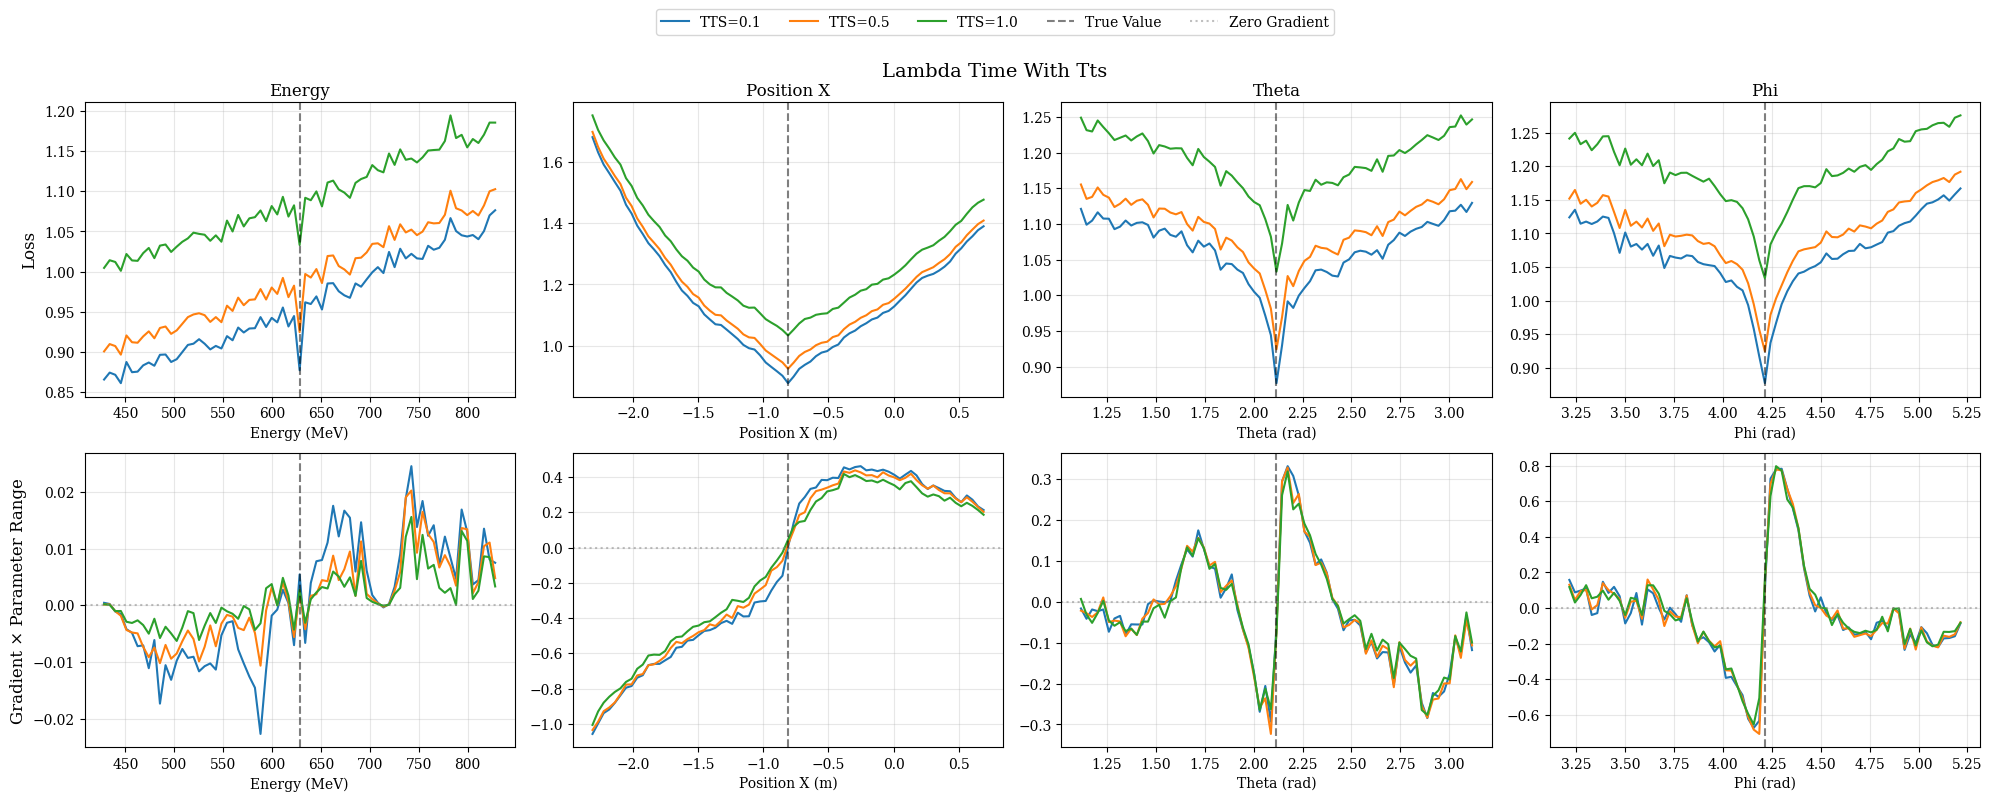

In [10]:
# Generate parameter ranges
num_points = 71
param_ranges = generate_param_ranges(true_params, param_changes, num_points)
param_names = ['Energy', 'Position X', 'Theta', 'Phi']

# Lambda Time Analysis with TTS variations (lambda_time=1, others=0)
# Only using temperature = 0.0
print("Running Lambda Time Analysis with TTS variations (T=0.0 only)...")

tts_values = [0.1, 0.5, 1.0]  # Transit time spread values to test

analysis_time = {
    'param_ranges': param_ranges,
    'param_names': param_names,
    'particle_params': true_params,
    'case': 'lambda_time_with_tts',
    'results': {},
    'labels': {}
}

# Only use temperature = 0.0
temp = 0.0
simulator = event_simulators[temp]

for tts in tts_values:
    # Generate noised data with specific TTS
    noised_data_tts = add_detector_noise(true_data, noise_key, tts=tts)
    
    condition_key = f'tts_{tts}'
    analysis_time['results'][condition_key] = {}
    analysis_time['labels'][condition_key] = f'TTS={tts}'
    
    for param_idx, param_name in enumerate(tqdm(param_names, desc=f"Time TTS={tts}")):
        param_values = param_ranges[param_idx]
        losses, gradients = generate_plot_data_wc(
            param_idx, param_values, simulator,
            true_params, detector_params, key, noised_data_tts, detector_points,
            lambda_poisson=0.0, lambda_time=1.0
        )
        analysis_time['results'][condition_key][param_name] = {
            'losses': losses,
            'gradients': gradients
        }

# Plot results
fig_time = plot_analysis_results(analysis_time)
plt.savefig('../figures/analysis_lambda_time_tts_noised.pdf', dpi=300, bbox_inches='tight')
plt.show()

## Temperature Gradient Analysis (Similar to temperature_gradient_analysis_scaled.py)

In [12]:
# Temperature analysis with lambda_poisson=1 (replaces lambda_charge from before)
print("\nRunning Temperature Gradient Analysis with lambda_poisson=1...")

# Store all results
temperature_analysis = {
    'param_ranges': param_ranges,
    'param_names': param_names,
    'temperatures': temperatures,
    'particle_params': true_params,
    'case': 'temperature_gradient_poisson',
    'results': {}
}

# Process each temperature
for temp in temperatures:
    simulator = event_simulators[temp]
    temp_key = f'temp_{temp}'
    temperature_analysis['results'][temp_key] = {}
    
    # Create loss and gradient function for this specific simulator
    @jit
    def loss_and_grad_fn(p_params, d_params):
        def loss_fn(p):
            simulated_data = simulator(p, d_params, key)
            return WC_loss(
                detector_points, *true_data, *simulated_data,
                lambda_poisson=1.0,
                lambda_time=0.0
            )
        return value_and_grad(loss_fn)(p_params)
    
    print(f"\nProcessing temperature {temp}...")
    
    for param_idx, param_name in enumerate(tqdm(param_names, desc=f"T={temp}")):
        param_values = param_ranges[param_idx]
        losses = []
        gradients = []
        
        for new_value in param_values:
            # Modify particle parameter
            new_p_params = list(true_params)
            
            if param_idx == 0:  # Energy
                new_p_params[0] = new_value
            elif param_idx == 1:  # Position X
                new_p_params[1] = new_p_params[1].at[0].set(new_value)
            elif param_idx == 2:  # Theta
                new_p_params[2] = new_p_params[2].at[0].set(new_value)
            elif param_idx == 3:  # Phi
                new_p_params[2] = new_p_params[2].at[1].set(new_value)
            
            new_p_params = tuple(new_p_params)
            
            # Calculate loss and gradient WITHOUT parameter range scaling
            loss, grad_val = loss_and_grad_fn(new_p_params, detector_params)
            
            # Extract gradient for specific parameter (no scaling)
            if param_idx == 0:  # Energy
                gradient = grad_val[0]
            elif param_idx == 1:  # Position X
                gradient = grad_val[1][0]
            elif param_idx == 2:  # Theta
                gradient = grad_val[2][0]
            elif param_idx == 3:  # Phi
                gradient = grad_val[2][1]
            
            # NO parameter range scaling - keep raw gradients
            losses.append(float(loss))
            gradients.append(float(gradient))
        
        temperature_analysis['results'][temp_key][param_name] = {
            'losses': jnp.array(losses),
            'gradients': jnp.array(gradients)
        }

# Calculate numerical gradients for T=0.0
print("\nCalculating numerical gradients for T=0.0...")
temp_0_key = 'temp_0.0'
for param_name in param_names:
    losses = np.array(temperature_analysis['results'][temp_0_key][param_name]['losses'])
    param_idx = param_names.index(param_name)
    param_values = np.array(param_ranges[param_idx])
    
    # Calculate numerical gradient (raw, no scaling)
    numerical_grad = calculate_numerical_gradient(losses, param_values)
    
    # Store numerical gradient (no parameter range scaling)
    temperature_analysis['results'][temp_0_key][param_name]['numerical_gradients'] = numerical_grad

# Now scale all gradients by their 99th percentile for each temperature and parameter
print("\nScaling gradients by 99th percentile...")
for temp_key in temperature_analysis['results'].keys():
    for param_name in param_names:
        # Scale analytical gradients
        gradients = np.array(temperature_analysis['results'][temp_key][param_name]['gradients'])
        scaled_gradients = scale_gradients_by_percentile(gradients, percentile=99)
        temperature_analysis['results'][temp_key][param_name]['scaled_gradients'] = scaled_gradients
        
        # Scale numerical gradients if they exist
        if 'numerical_gradients' in temperature_analysis['results'][temp_key][param_name]:
            num_gradients = np.array(temperature_analysis['results'][temp_key][param_name]['numerical_gradients'])
            scaled_num_gradients = scale_gradients_by_percentile(num_gradients, percentile=99)
            temperature_analysis['results'][temp_key][param_name]['scaled_numerical_gradients'] = scaled_num_gradients


Running Temperature Gradient Analysis with lambda_poisson=1...

Processing temperature 0.0...


T=0.0: 100%|██████████| 4/4 [01:00<00:00, 15.24s/it]



Processing temperature 0.2...


T=0.2: 100%|██████████| 4/4 [01:08<00:00, 17.10s/it]


Calculating numerical gradients for T=0.0...

Scaling gradients by 99th percentile...



Generating temperature gradient analysis plots...


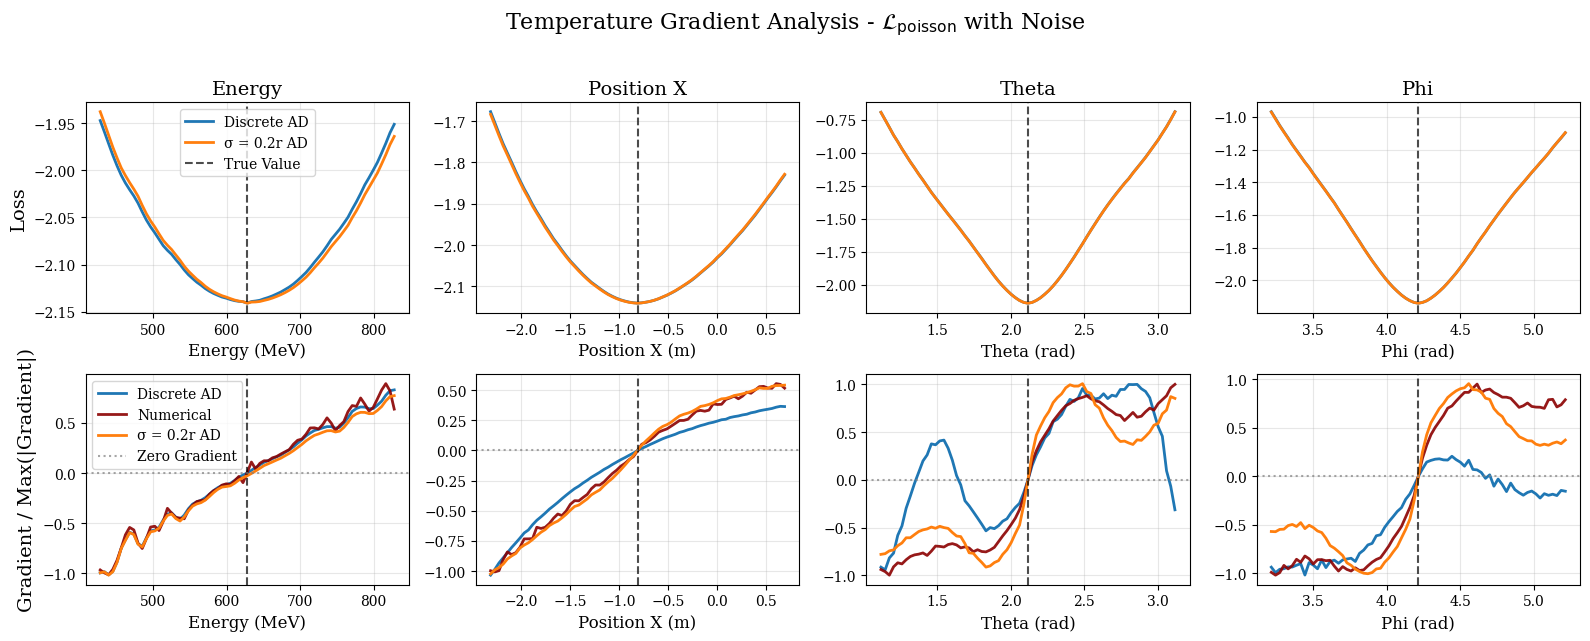


Analysis complete!
Temperatures analyzed: [0.0, 0.2]
Gradients scaled by 99th percentile for each temperature


In [13]:
# Plot temperature gradient analysis
print("\nGenerating temperature gradient analysis plots...")

# Color palette
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# Figure size appropriate for paper
fig, axs = plt.subplots(2, 4, figsize=(16, 6.5))

for param_idx, param_name in enumerate(param_names):
    ax_loss = axs[0, param_idx]
    ax_grad = axs[1, param_idx]
    
    param_values = param_ranges[param_idx]
    
    # Determine true value
    if param_idx == 0:  # Energy
        true_value = true_params[0]
    elif param_idx == 1:  # Position X
        true_value = true_params[1][0]
    elif param_idx == 2:  # Theta
        true_value = true_params[2][0]
    elif param_idx == 3:  # Phi
        true_value = true_params[2][1]
    
    # Plot for each temperature
    for temp_idx, temp in enumerate(temperatures):
        temp_key = f'temp_{temp}'
        results = temperature_analysis['results'][temp_key][param_name]
        
        # Create label with sigma symbol
        if temp == 0.0:
            label = 'Discrete AD'
        else:
            label = f'σ = {temp}r AD'
        color = colors[temp_idx]
        
        # Plot losses
        ax_loss.plot(param_values, results['losses'], 
                    color=color, lw=2.0, label=label)
        
        # Plot scaled analytical gradients
        ax_grad.plot(param_values, results['scaled_gradients'], 
                    color=color, lw=2.0, label=label)
        
        # Plot scaled numerical gradient for T=0.0
        if temp == 0.0 and 'scaled_numerical_gradients' in results:
            ax_grad.plot(param_values, results['scaled_numerical_gradients'], 
                       color='#8B0000', lw=2.0, linestyle='-', alpha=0.9,
                       label='Numerical')
    
    # Add reference lines
    ax_loss.axvline(x=true_value, color='black', linestyle='--', lw=1.5, alpha=0.7, 
                   label='True Value' if param_idx == 0 else '')
    ax_grad.axvline(x=true_value, color='black', linestyle='--', lw=1.5, alpha=0.7)
    ax_grad.axhline(y=0, color='gray', linestyle=':', lw=1.5, alpha=0.7, 
                   label='Zero Gradient' if param_idx == 0 else '')
    
    # Configure axes
    ax_loss.set_title(f'{param_name}', fontsize=14)
    
    # Set x-labels
    if param_name == 'Energy':
        xlabel = f'{param_name} (MeV)'
    elif param_name == 'Position X':
        xlabel = f'{param_name} (m)'
    else:  # Theta, Phi
        xlabel = f'{param_name} (rad)'
    
    ax_loss.set_xlabel(xlabel, fontsize=12)
    ax_grad.set_xlabel(xlabel, fontsize=12)
    
    # Y-labels for leftmost plots
    if param_idx == 0:
        ax_loss.set_ylabel('Loss', fontsize=14)
        ax_grad.set_ylabel('Gradient / Max(|Gradient|)', fontsize=14)
        ax_loss.legend(fontsize=10, loc='best')
        ax_grad.legend(fontsize=10, loc='best')
    
    ax_loss.grid(True, alpha=0.3)
    ax_grad.grid(True, alpha=0.3)

# Use mathcal for the title
fig.suptitle(r'Temperature Gradient Analysis - $\mathcal{L}_{\mathrm{poisson}}$ with Noise', 
             fontsize=16, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save figure
plt.savefig('../figures/temperature_gradient_analysis_poisson_noised.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nAnalysis complete!")
print(f"Temperatures analyzed: {temperatures}")
print("Gradients scaled by 99th percentile for each temperature")

## Save Results

In [ ]:
# Create output directory if it doesn't exist
Path('../output').mkdir(exist_ok=True)

# Save all analysis results
with open('../output/analysis_time_tts_noised.pkl', 'wb') as f:
    pickle.dump(analysis_time, f)

with open('../output/temperature_analysis_poisson_noised.pkl', 'wb') as f:
    pickle.dump(temperature_analysis, f)

print("All results saved to ../output/")